# How the diffusion rate shapes the drift likelihood

`sigma` is held fixed when fitting, so the question is which value to fix it at. This
notebook profiles the log-likelihood over `mu` at four values of `sigma`.

The point is the **number of peaks**. At a poorly chosen `sigma` the likelihood breaks into
many comparable modes separated by troughs, and MCMC chains started at random land in
different ones and cannot cross. That is a property of the likelihood, not of the sampler,
which is why more chains, longer warmup and more draws do not help. At a well chosen
`sigma` it collapses to a single dominant mode and the same sampler converges.

Trials are drawn to match the composition of the observed data - three response types,
response times spread over the observed range - rather than generated from the model. That
matters: data generated by the model is fitted too cleanly and the multimodality does not
appear. The problem is a property of fitting this model to data it did not generate, which
is the situation that actually obtains.

In [1]:
import numpy as np, jax, jax.numpy as npx, pandas as pd
from plotnine import *
import cme.decision_models.confidence_accumulation as ca

n_states, response_width, n_bins = 51, 17, 7
delta, measurement_prob, n_trials = 0.1, 0.75, 30

sigmas = [3.0, 6.0, 12.0, 20.0]
neutral_shares = [0.0, 0.3, 0.6]
mu_grid = np.linspace(0.05, 3.0, 300)

n_free = n_states - 2 * response_width
Mc, Mw, Mn = ca._get_measurement_matrix(n_states, response_width, measurement_prob, "Quantum")
conc = ca._initial_state_concentration(n_bins, "Quantum")
phi_0 = npx.sqrt(npx.pad(ca._expand_bins(conc / conc.sum(), n_free, n_bins),
                         (response_width, response_width)))[None, None, :, None]

g++ not available, if using conda: `conda install gxx`


## Likelihood profile over the drift rate

In [2]:
def trials(p_neutral, rng):
    p = [(1 - p_neutral) * 0.6, (1 - p_neutral) * 0.4, p_neutral]
    return (rng.uniform(1.0, 9.0, (1, n_trials)),
            rng.choice([1, -1, 0], size=(1, n_trials), p=p))


def profile(RT, RA, sigma):
    def one(mu):
        G = ca.quantum_buildH(n_states, npx.full((1, 1), mu), npx.full((1, 1), sigma), delta)
        P = ca.likelihood(G, phi_0, delta, RT, RA, Mc, Mw, Mn,
                          transition_type="TIMESTEP", likelihood_type="SINGLE", model_type="Quantum")
        return npx.log(npx.clip(npx.where(npx.isnan(P), 1e-12, P), 1e-15, 1.0)).sum()
    return np.asarray(jax.jit(jax.vmap(one))(npx.asarray(mu_grid)))


def n_peaks(ll):
    return len(np.where((ll[1:-1] > ll[:-2]) & (ll[1:-1] > ll[2:]))[0])

In [3]:
rng = np.random.default_rng(0)
rows, counts = [], []
for pn in neutral_shares:
    RT, RA = trials(pn, rng)
    for s in sigmas:
        ll = profile(RT, RA, s)
        rows.append(pd.DataFrame({"mu": mu_grid, "ll": ll - ll.max(),
                                  "sigma": f"{s:g}", "panel": f"{pn:.0%} neutral trials"}))
        counts.append({"neutral": f"{pn:.0%}", "sigma": s, "peaks": n_peaks(ll)})

prof = pd.concat(rows)
prof["sigma"] = pd.Categorical(prof.sigma, [f"{s:g}" for s in sigmas])
prof["panel"] = pd.Categorical(prof.panel, [f"{p:.0%} neutral trials" for p in neutral_shares])

print(pd.DataFrame(counts).pivot(index="neutral", columns="sigma", values="peaks").to_string())

sigma    3.0   6.0   12.0  20.0
neutral                        
0%         18    12     3     4
30%        15     7     1     3
60%        10     5     0     3


Each curve is shifted so its own maximum sits at zero - log-likelihoods at different `sigma`
are on very different scales, and only the shape is being compared. The dot marks each
curve's maximum.

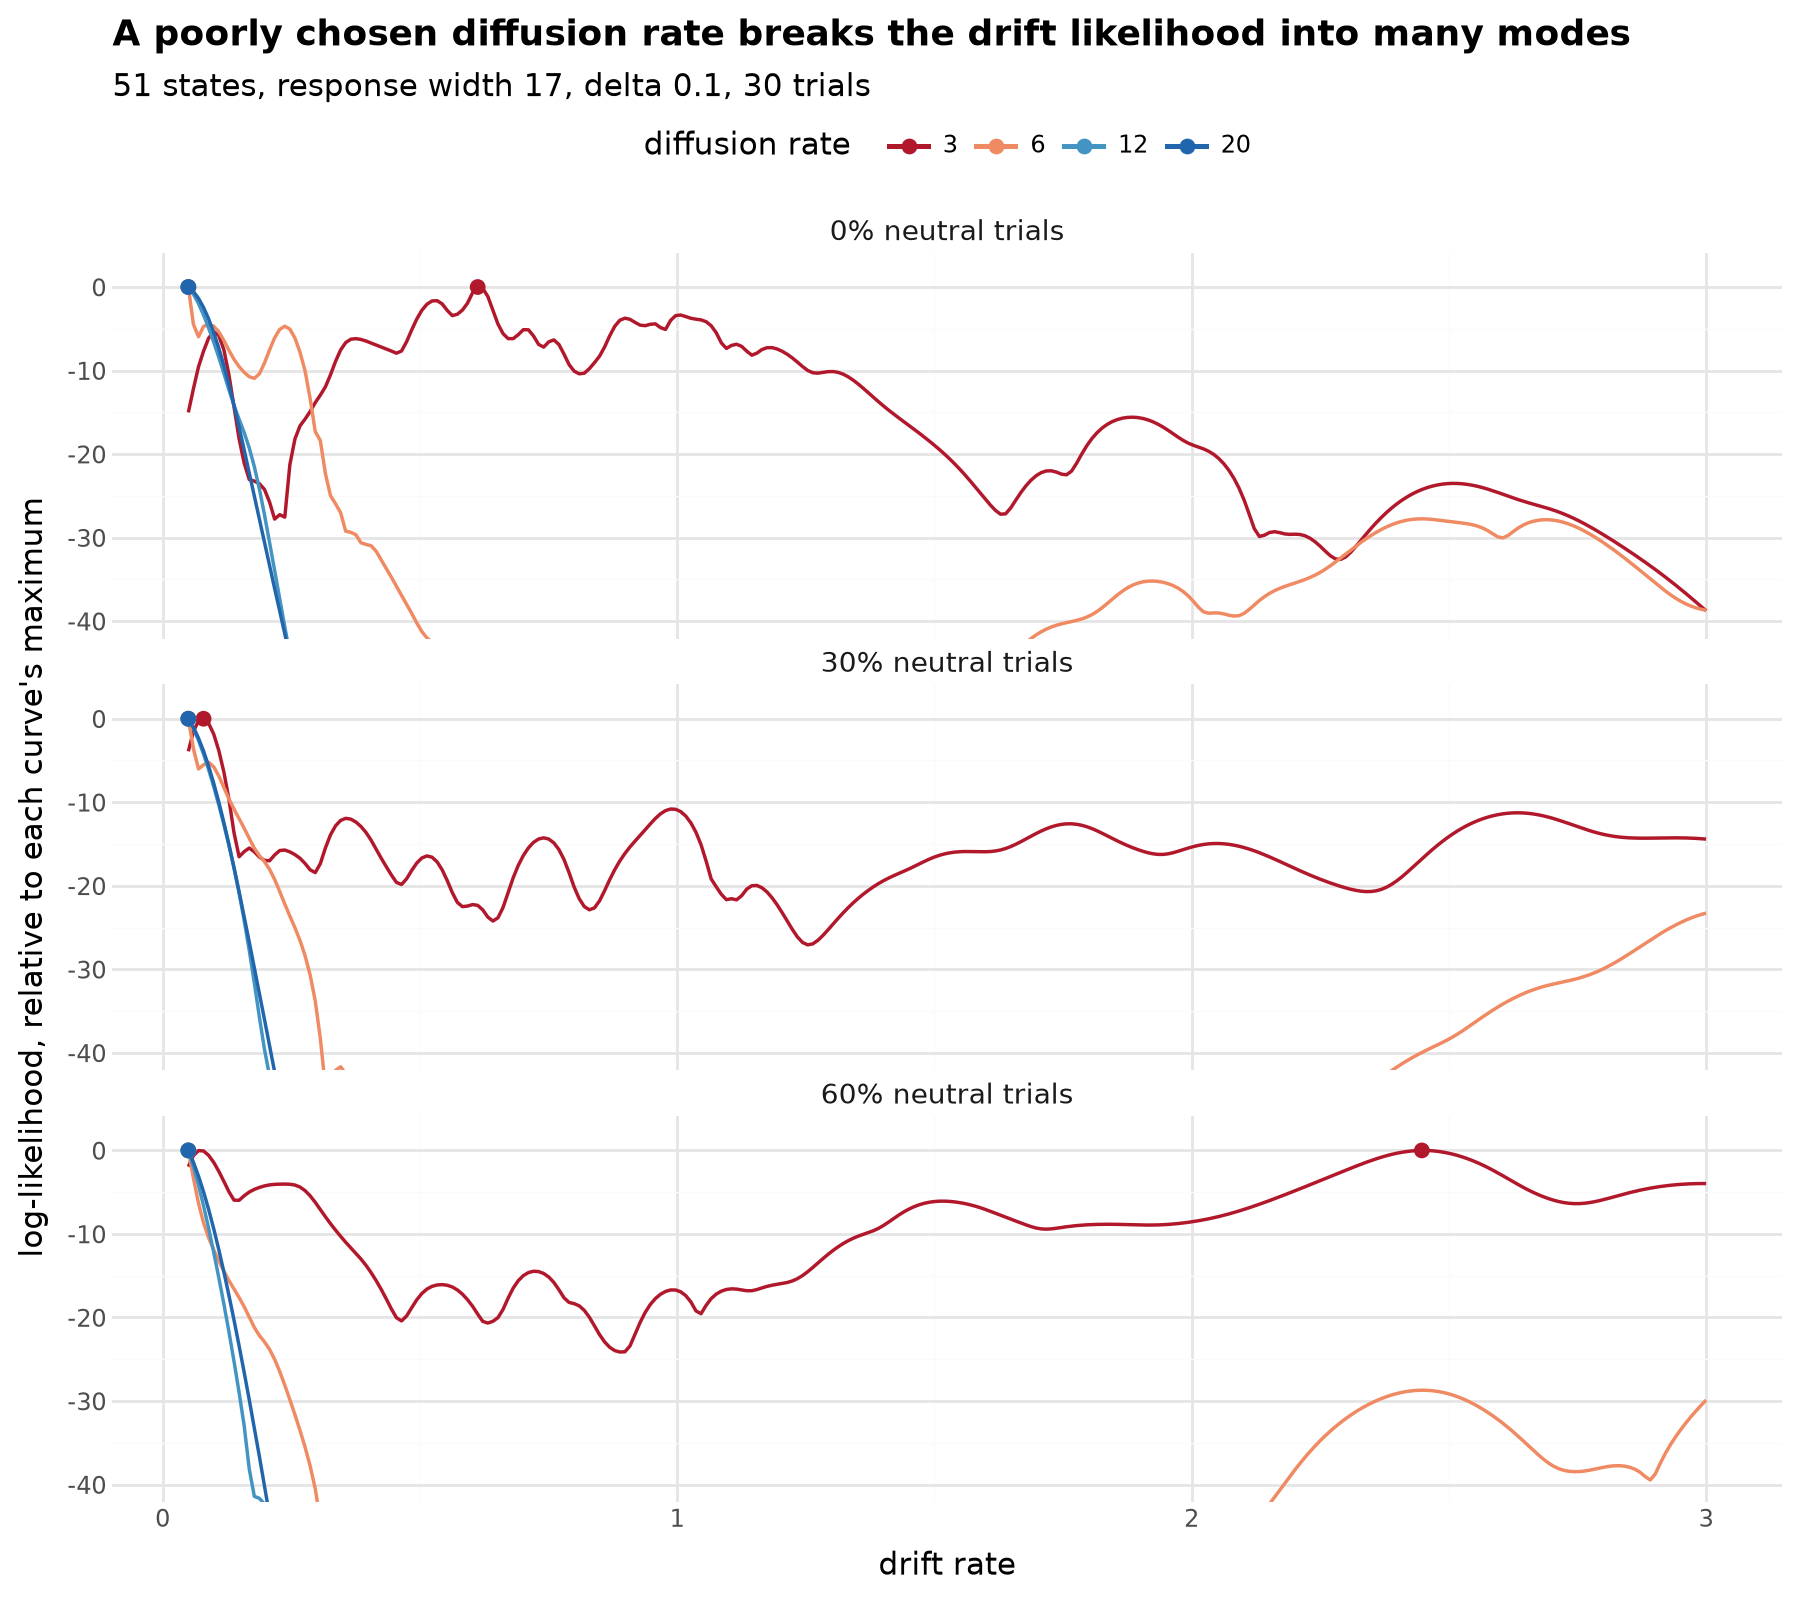

In [4]:
peak_marks = pd.concat([prof[prof.panel.eq(p) & prof.sigma.eq(s)].nlargest(1, "ll")
                        for p in prof.panel.cat.categories for s in prof.sigma.cat.categories])

(ggplot(prof, aes("mu", "ll", colour="sigma"))
 + geom_line(size=0.7)
 + geom_point(peak_marks, size=2.2)
 + facet_wrap("~panel", ncol=1)
 + scale_colour_manual(["#b2182b", "#ef8a62", "#4393c3", "#2166ac"], name="diffusion rate")
 + coord_cartesian(ylim=(-40, 2))
 + labs(x="drift rate", y="log-likelihood, relative to each curve's maximum",
        title="A poorly chosen diffusion rate breaks the drift likelihood into many modes",
        subtitle=f"{n_states} states, response width {response_width}, delta {delta}, {n_trials} trials")
 + theme_minimal()
 + theme(figure_size=(9, 8), legend_position="top",
         plot_title=element_text(size=13, weight="bold"), strip_text=element_text(size=10)))

## What to read from it

At **sigma 3** the curve is a picket fence of comparable modes, and the troughs between them
are what trap the chains. At **sigma 12** there is one dominant mode.

The maxima also move with `sigma`: the diffusion rate you fix determines which drift the
data appears to support. The two parameters cannot be chosen independently, which is why
`sigma` has to be set before `mu` can be estimated.

The rule this gives: **choose `sigma` so that the drift likelihood has one dominant mode and
the rest are ripples.** Applied across grids it yields 5 at 21 states, 12 at 51 and 24 at
101 - which in units of the free region is 0.71, 0.71 and 0.73, the same process on three
different lattices.